In [81]:
#importing the needed libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#importing the prices data and log_returns from the previous notebook
prices = pd.read_csv("prices.csv", index_col=0, parse_dates=True)
log_returns = pd.read_csv("log_returns.csv", index_col=0, parse_dates=True)
tickers = ["SPY", "QQQ", "TLT", "GLD", "XLE"]

In [82]:
#finding the daily means returns

daily_mean_returns = log_returns.mean()

print(daily_mean_returns)


GLD    0.000450
QQQ    0.000676
SPY    0.000501
TLT   -0.000030
XLE    0.000200
dtype: float64


In [83]:
#annualzing the daily means returns

annual_mean_returns = daily_mean_returns *252

print(annual_mean_returns)

GLD    0.113495
QQQ    0.170330
SPY    0.126287
TLT   -0.007620
XLE    0.050411
dtype: float64


In [84]:
#calculating daily volatility

daily_volatility = log_returns.std()

print(daily_volatility)

GLD    0.009295
QQQ    0.013868
SPY    0.011232
TLT    0.009473
XLE    0.018614
dtype: float64


In [85]:
#annualizing the volatility

annual_volatility = daily_volatility * np.sqrt(252)

print(annual_volatility)

GLD    0.147556
QQQ    0.220142
SPY    0.178309
TLT    0.150374
XLE    0.295494
dtype: float64


In [86]:
#taking a look at the correlation matrix

correlation_matrix = log_returns.corr()

print(correlation_matrix)

          GLD       QQQ       SPY       TLT       XLE
GLD  1.000000  0.051767  0.043838  0.280692  0.058138
QQQ  0.051767  1.000000  0.933831 -0.131250  0.445942
SPY  0.043838  0.933831  1.000000 -0.184280  0.627056
TLT  0.280692 -0.131250 -0.184280  1.000000 -0.242897
XLE  0.058138  0.445942  0.627056 -0.242897  1.000000


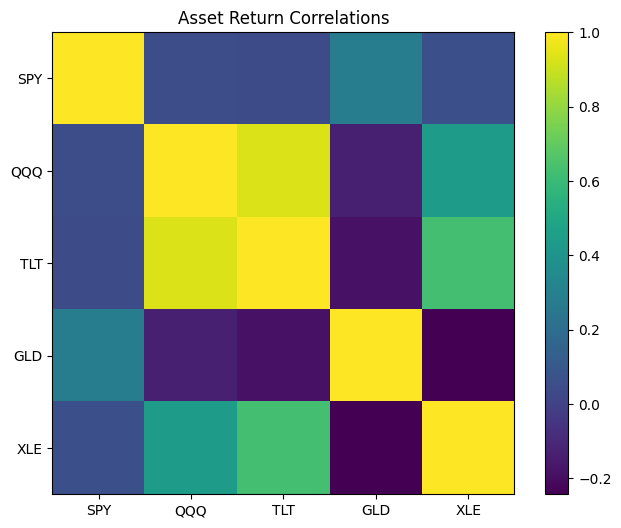

In [87]:
#plotting out the correlation matrix


plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix)

plt.xticks(
    range(len(tickers)),
    tickers
)

plt.yticks(
    range(len(tickers)),
    tickers
)

plt.colorbar()

plt.title("Asset Return Correlations")
plt.show()


In [88]:
#creating the covarience matrix

covariance_matrix = log_returns.cov()

print(covariance_matrix)

          GLD       QQQ       SPY       TLT       XLE
GLD  0.000086  0.000007  0.000005  0.000025  0.000010
QQQ  0.000007  0.000192  0.000145 -0.000017  0.000115
SPY  0.000005  0.000145  0.000126 -0.000020  0.000131
TLT  0.000025 -0.000017 -0.000020  0.000090 -0.000043
XLE  0.000010  0.000115  0.000131 -0.000043  0.000346


In [89]:
#annualizing the covarience matrix

annual_covariance_matrix = covariance_matrix * 252

print(annual_covariance_matrix)

          GLD       QQQ       SPY       TLT       XLE
GLD  0.021773  0.001682  0.001153  0.006228  0.002535
QQQ  0.001682  0.048462  0.036656 -0.004345  0.029009
SPY  0.001153  0.036656  0.031794 -0.004941  0.033039
TLT  0.006228 -0.004345 -0.004941  0.022612 -0.010793
XLE  0.002535  0.029009  0.033039 -0.010793  0.087317


In [90]:
# creating a sample portfolio

weights = np.array([
    0.40,  # SPY
    0.20,  # QQQ
    0.20,  # TLT
    0.05,  # GLD
    0.15   # XLE
])

print(weights.sum())

1.0


In [91]:
#calculating expected portfolio return for sample portfolio

portfolio_return = weights @ annual_mean_returns

print(portfolio_return)

0.11190222206508003


In [92]:
#calculating portfolio varience for the sample portfolio

portfolio_variance = (
    weights.T
    @ annual_covariance_matrix
    @ weights
)

print('portfolio varience =' , portfolio_variance)

portfolio_volatility = np.sqrt(portfolio_variance)

print('portfolio volatility =' , portfolio_volatility)

print(f"{portfolio_volatility:.2%}")

portfolio varience = 0.01602968021483398
portfolio volatility = 0.12660837339936873
12.66%


In [93]:
#calculating asset volatility

asset_volatility = log_returns.std() * np.sqrt(252)

print(asset_volatility)

GLD    0.147556
QQQ    0.220142
SPY    0.178309
TLT    0.150374
XLE    0.295494
dtype: float64


In [99]:
#conducting a mini experiment(comparing two portfolios Volatilities )


#making weight_A to compare to the sample portfolio constructed earlier
weights_A = np.array([
    1.0,
    0.0,
    0.0,
    0.0,
    0.0
])

#finding the volatility of portfolio A(not the sample one)


portfolio_variance_A = (
    weights.T
    @ annual_covariance_matrix
    @ weights_A )
portfolio_volatility_A = np.sqrt(portfolio_variance_A)


print('sample portfolio Volatility: ', portfolio_volatility * 100 ,'%')
print('sample portfolio A Volatility: ' , portfolio_volatility_A * 100, '%')



sample portfolio Volatility:  12.660837339936872 %
sample portfolio A Volatility:  9.983835277192094 %
